In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
df = pd.read_csv('bank.csv')
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [5]:
#Q6: Data Understanding

print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Shape: (11162, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
#Q7: Data Cleaning

print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total Missing Values:
0

Duplicate Rows:
0


In [7]:
#Q8: Categorical Encoding

df['deposit'] = df['deposit'].map({
    'no': 0,
    'yes': 1
})

print(df['deposit'].value_counts())

deposit
0    5873
1    5289
Name: count, dtype: int64


In [8]:
X = df.drop('deposit', axis=1)
y = df['deposit']

In [9]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

Numerical Columns:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [11]:
#Q9: Feature Selection & Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8929, 16)
Testing data: (2233, 16)


In [12]:
#Q10: Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [14]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
#Q11: Model Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8034034930586654

Confusion Matrix:
[[946 229]
 [210 848]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1175
           1       0.79      0.80      0.79      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



In [16]:
#Q12: Overfitting Check

train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8077052301489529
Testing Accuracy: 0.8034034930586654


In [17]:
#Q13: Pruning Experiment

pruned_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

In [18]:
pruned_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', pruned_model)
    ]
)

In [19]:
pruned_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
pruned_train_pred = pruned_pipeline.predict(X_train)
pruned_test_pred = pruned_pipeline.predict(X_test)

pruned_train_accuracy = accuracy_score(
    y_train,
    pruned_train_pred
)

pruned_test_accuracy = accuracy_score(
    y_test,
    pruned_test_pred
)

print("Pruned Training Accuracy:", pruned_train_accuracy)
print("Pruned Testing Accuracy:", pruned_test_accuracy)

Pruned Training Accuracy: 0.7785866278418636
Pruned Testing Accuracy: 0.7801164352888491


In [21]:
#Q14: Feature Importance

tree_model = pipeline.named_steps['model']
preprocessor_fitted = pipeline.named_steps['preprocessor']

In [22]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [23]:
importance = tree_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(5))

                  Feature  Importance
47    remainder__duration    0.606230
42  cat__poutcome_success    0.159335
27   cat__contact_unknown    0.141635
22       cat__housing_yes    0.036343
35         cat__month_mar    0.032731


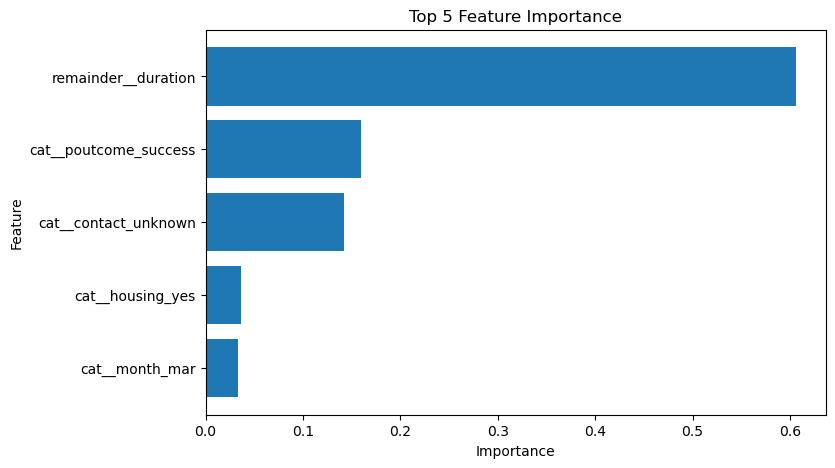

In [24]:
top5 = feature_importance.head(5)

plt.figure(figsize=(8,5))
plt.barh(top5['Feature'], top5['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 5 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [25]:
#Q15 Business Insights

for col in ['job', 'marital', 'education', 'housing', 
            'loan', 'contact', 'poutcome']:
    
    print(f"\n{col.upper()}")
    
    yes_rate = (
        df.groupby(col)['deposit']
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(yes_rate.round(2))


JOB
job
admin.           0.0
blue-collar      0.0
entrepreneur     0.0
housemaid        0.0
management       0.0
retired          0.0
self-employed    0.0
services         0.0
student          0.0
technician       0.0
unemployed       0.0
unknown          0.0
Name: deposit, dtype: float64

MARITAL
marital
divorced    0.0
married     0.0
single      0.0
Name: deposit, dtype: float64

EDUCATION
education
primary      0.0
secondary    0.0
tertiary     0.0
unknown      0.0
Name: deposit, dtype: float64

HOUSING
housing
no     0.0
yes    0.0
Name: deposit, dtype: float64

LOAN
loan
no     0.0
yes    0.0
Name: deposit, dtype: float64

CONTACT
contact
cellular     0.0
telephone    0.0
unknown      0.0
Name: deposit, dtype: float64

POUTCOME
poutcome
failure    0.0
other      0.0
success    0.0
unknown    0.0
Name: deposit, dtype: float64


In [26]:
for col in ['job', 'marital', 'education', 
            'housing', 'loan', 'contact', 'poutcome']:
    
    yes_rate = (
        df.groupby(col)['deposit']
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(f"\nTop {col} groups:")
    print(yes_rate.head(3).round(2))


Top job groups:
job
admin.          0.0
blue-collar     0.0
entrepreneur    0.0
Name: deposit, dtype: float64

Top marital groups:
marital
divorced    0.0
married     0.0
single      0.0
Name: deposit, dtype: float64

Top education groups:
education
primary      0.0
secondary    0.0
tertiary     0.0
Name: deposit, dtype: float64

Top housing groups:
housing
no     0.0
yes    0.0
Name: deposit, dtype: float64

Top loan groups:
loan
no     0.0
yes    0.0
Name: deposit, dtype: float64

Top contact groups:
contact
cellular     0.0
telephone    0.0
unknown      0.0
Name: deposit, dtype: float64

Top poutcome groups:
poutcome
failure    0.0
other      0.0
success    0.0
Name: deposit, dtype: float64
